In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv("housing.csv")

In [ ]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
data.dropna(inplace=True)
#returns a new DataFrame with rows containing any NaN values removed.
# this (inplace=True) taks data, drops nand values and save it

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


split data into **training and testing data** and split it into X and Y data

In [ ]:
from sklearn.model_selection import train_test_split
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [ ]:
X_train, x_test , y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [ ]:
train_data = X_train.join(y_train)

In [ ]:
train_data
#we have it only for train data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
930,-122.04,37.55,23.0,3170.0,532.0,1446.0,515.0,4.4357,NEAR BAY,291700.0
20065,-120.40,38.00,17.0,2098.0,370.0,912.0,354.0,2.6544,INLAND,112600.0
4395,-118.28,34.08,52.0,2465.0,773.0,2328.0,746.0,2.6178,<1H OCEAN,203100.0
3051,-119.36,35.55,29.0,510.0,84.0,236.0,73.0,2.7000,INLAND,125000.0
10469,-117.72,33.53,14.0,1672.0,295.0,704.0,293.0,5.1129,<1H OCEAN,251300.0
...,...,...,...,...,...,...,...,...,...,...
948,-121.91,37.71,25.0,4377.0,668.0,2038.0,671.0,5.7233,<1H OCEAN,231800.0
11148,-117.97,33.85,45.0,818.0,147.0,546.0,152.0,5.1057,<1H OCEAN,170700.0
4640,-118.29,34.06,23.0,2040.0,778.0,2235.0,697.0,1.9309,<1H OCEAN,233300.0
18577,-121.77,36.93,20.0,2587.0,547.0,1534.0,540.0,2.4375,<1H OCEAN,190400.0


exploration of numeric features

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

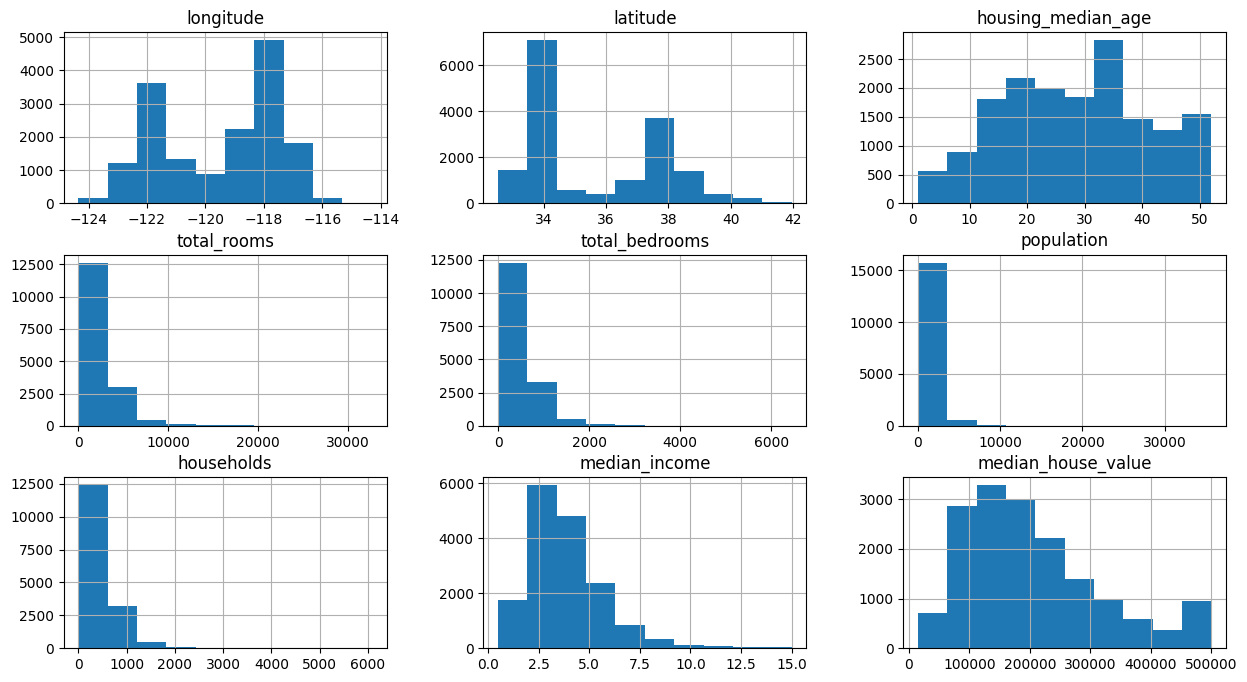

In [ ]:
train_data.hist(figsize=(15,8))
#distribution of the various features

In [ ]:
train_data.corr()
#matrix of the corr of all features

<ipython-input-13-b6ba361ccd20>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  train_data.corr()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924616,-0.107606,0.040958,0.065631,0.094968,0.051103,-0.017543,-0.046811
latitude,-0.924616,1.000000,0.010930,-0.033850,-0.064284,-0.105228,-0.068219,-0.078866,-0.143596
housing_median_age,-0.107606,0.010930,1.000000,-0.358310,-0.317166,-0.292451,-0.299152,-0.120118,0.106771
total_rooms,0.040958,-0.033850,-0.358310,1.000000,0.931220,0.856822,0.919852,0.201631,0.136126
total_bedrooms,0.065631,-0.064284,-0.317166,0.931220,1.000000,0.876229,0.978926,-0.005897,0.050966
population,0.094968,-0.105228,-0.292451,0.856822,0.876229,1.000000,0.906308,0.006640,-0.024091
households,0.051103,-0.068219,-0.299152,0.919852,0.978926,0.906308,1.000000,0.016252,0.066589
median_income,-0.017543,-0.078866,-0.120118,0.201631,-0.005897,0.006640,0.016252,1.000000,0.687772
median_house_value,-0.046811,-0.143596,0.106771,0.136126,0.050966,-0.024091,0.066589,0.687772,1.000000


<ipython-input-14-6ed6349ebe2f>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")


<Axes: >

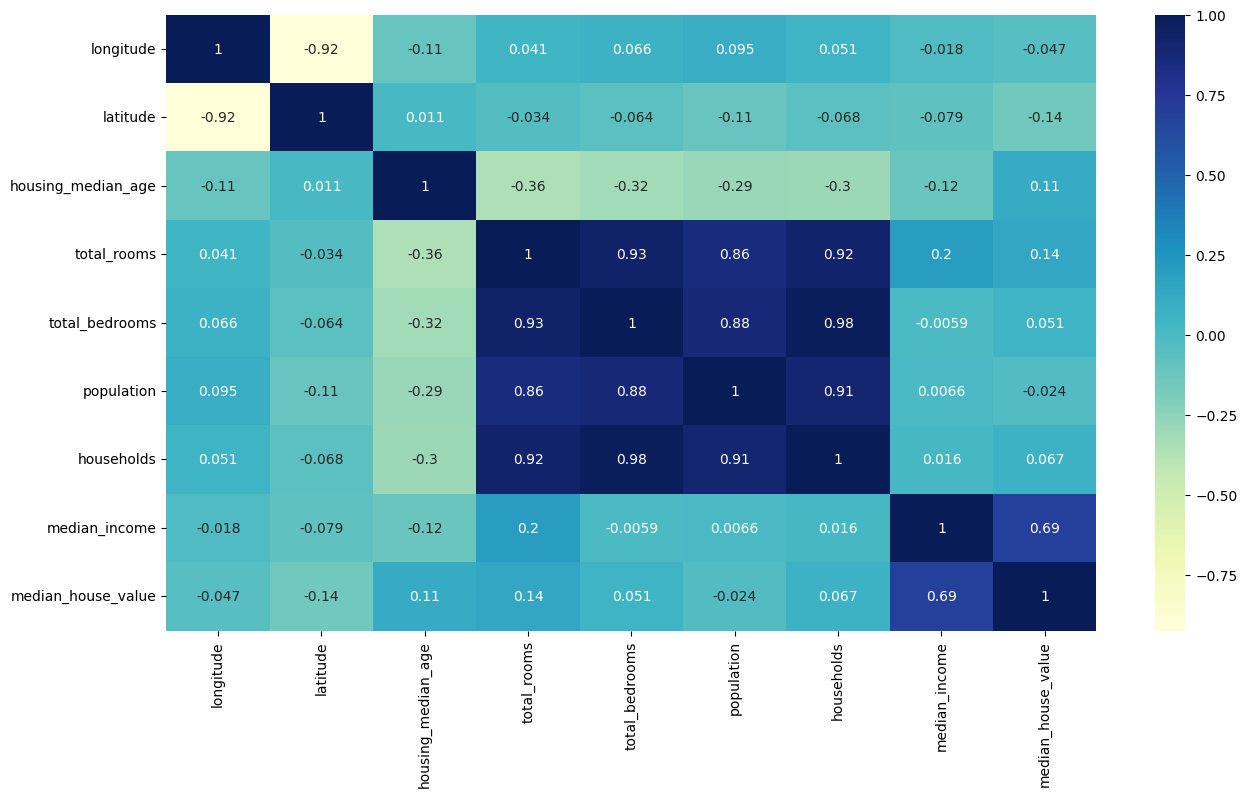

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
# annot=True for see the corralation numbers

as we can see data is right skewed.
it's not a nice gaussin bell curve.
SO  we're going to take the logarithm of those features and see what the distribution looks like.

---

NOTE : [
 Taking the logarithm of skewed data is a common technique in statistics and data analysis. When data is right-skewed, it means that there are a few very large values that are pulling the mean (average) towards them, making it an inaccurate representation of the central tendency of the data. In such cases, taking the logarithm of the data can often transform it into a more symmetrical distribution, which can be easier to work with and better suited for certain types of analysis.]



> pre-processing



In [ ]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1 )

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

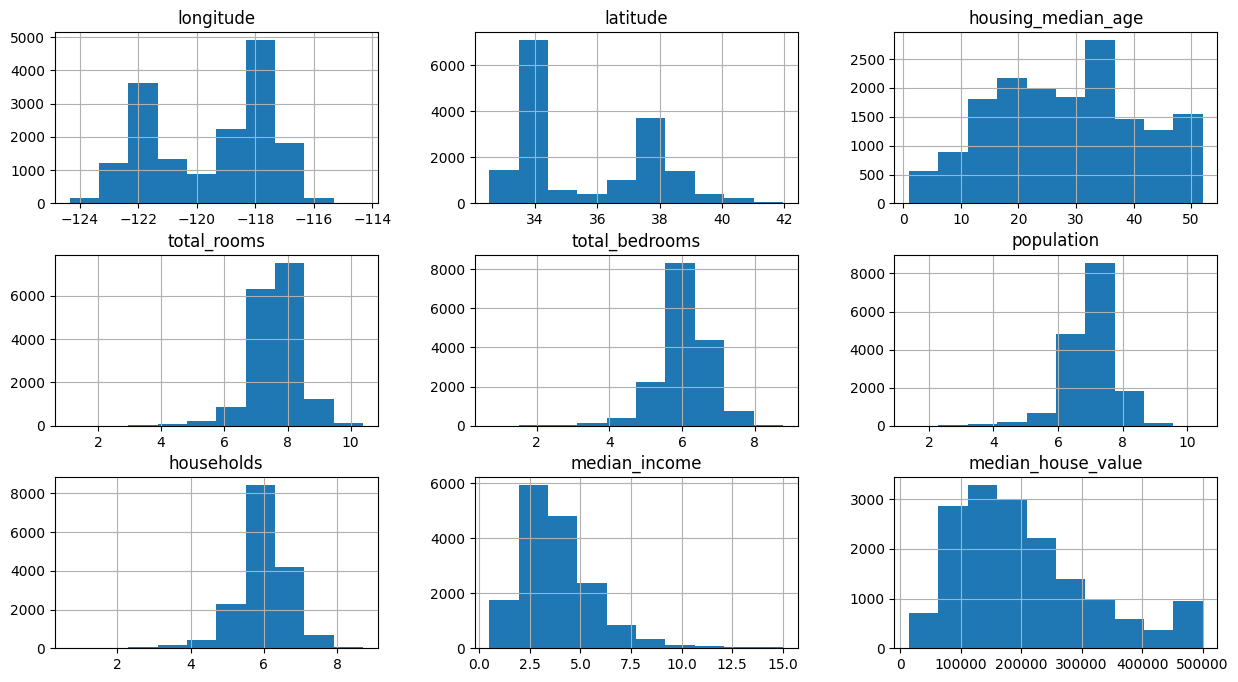

In [ ]:
train_data.hist(figsize=(15,8))
# now it's look like more to a normal dis.

In [ ]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
930,-122.04,37.55,23.0,8.061802,6.278521,7.277248,6.246107,4.4357,NEAR BAY,291700.0
20065,-120.40,38.00,17.0,7.649216,5.916202,6.816736,5.872118,2.6544,INLAND,112600.0
4395,-118.28,34.08,52.0,7.810353,6.651572,7.753194,6.616065,2.6178,<1H OCEAN,203100.0
3051,-119.36,35.55,29.0,6.236370,4.442651,5.468060,4.304065,2.7000,INLAND,125000.0
10469,-117.72,33.53,14.0,7.422374,5.690359,6.558198,5.683580,5.1129,<1H OCEAN,251300.0
...,...,...,...,...,...,...,...,...,...,...
948,-121.91,37.71,25.0,8.384347,6.505784,7.620215,6.510258,5.7233,<1H OCEAN,231800.0
11148,-117.97,33.85,45.0,6.708084,4.997212,6.304449,5.030438,5.1057,<1H OCEAN,170700.0
4640,-118.29,34.06,23.0,7.621195,6.658011,7.712444,6.548219,1.9309,<1H OCEAN,233300.0
18577,-121.77,36.93,20.0,7.858641,6.306275,7.336286,6.293419,2.4375,<1H OCEAN,190400.0


## ??

In [ ]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

<Axes: >

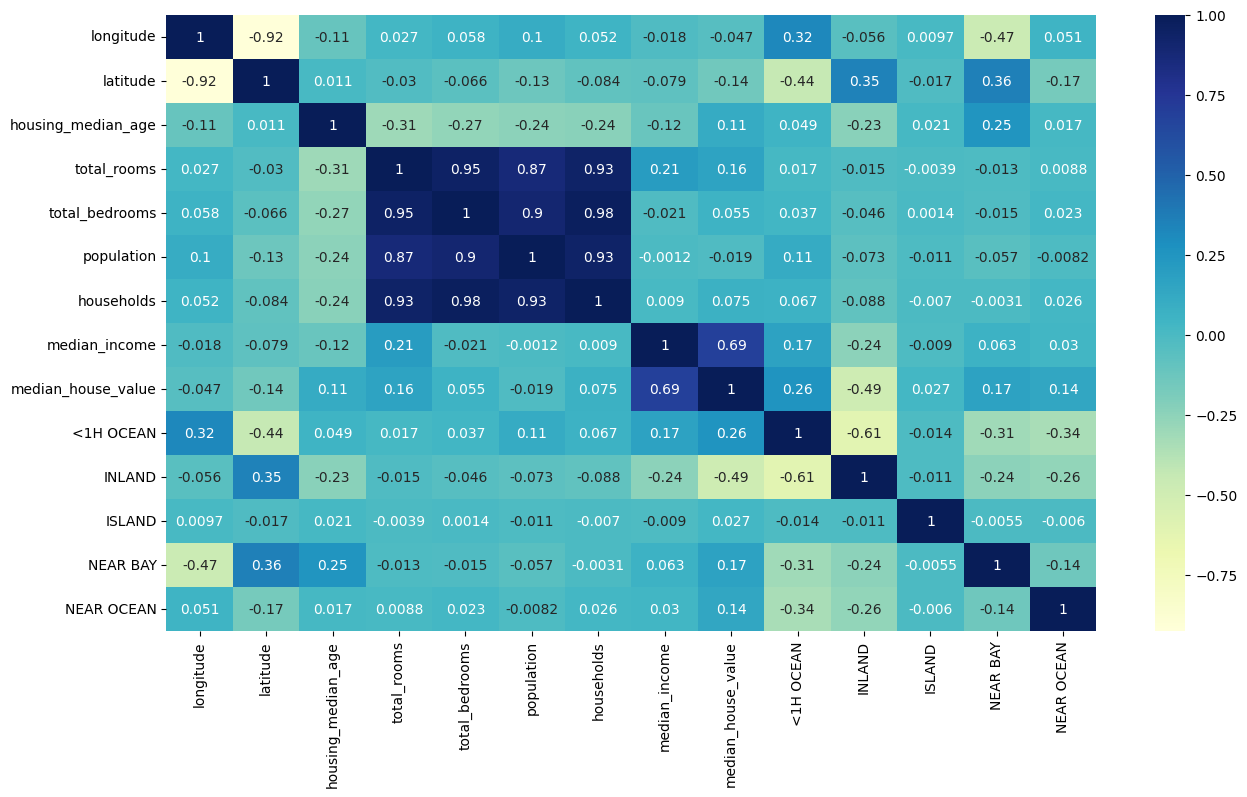

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

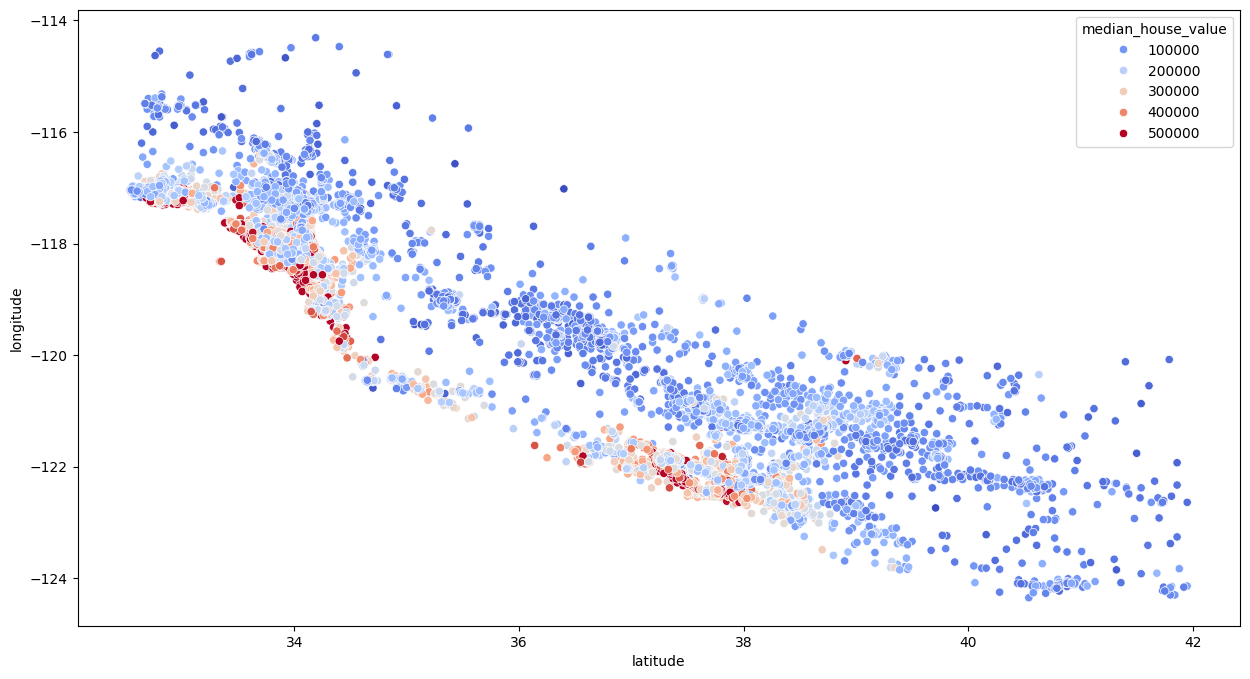

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot( x="latitude" , y= "longitude", data = train_data , hue = "median_house_value" , palette = "coolwarm")

# features engineering

take some features we have and combine it to new features


we engineering 2 features that seem to be important

کلا به اضافه کردن فیچر های جدید بر اساس فیچر هایی که داریم یا حذف کرددیم فیچر هایی که کرلیشن نزدیک به صفر دارن رو میگن فیچر انجیرینگ

In [ ]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['households_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

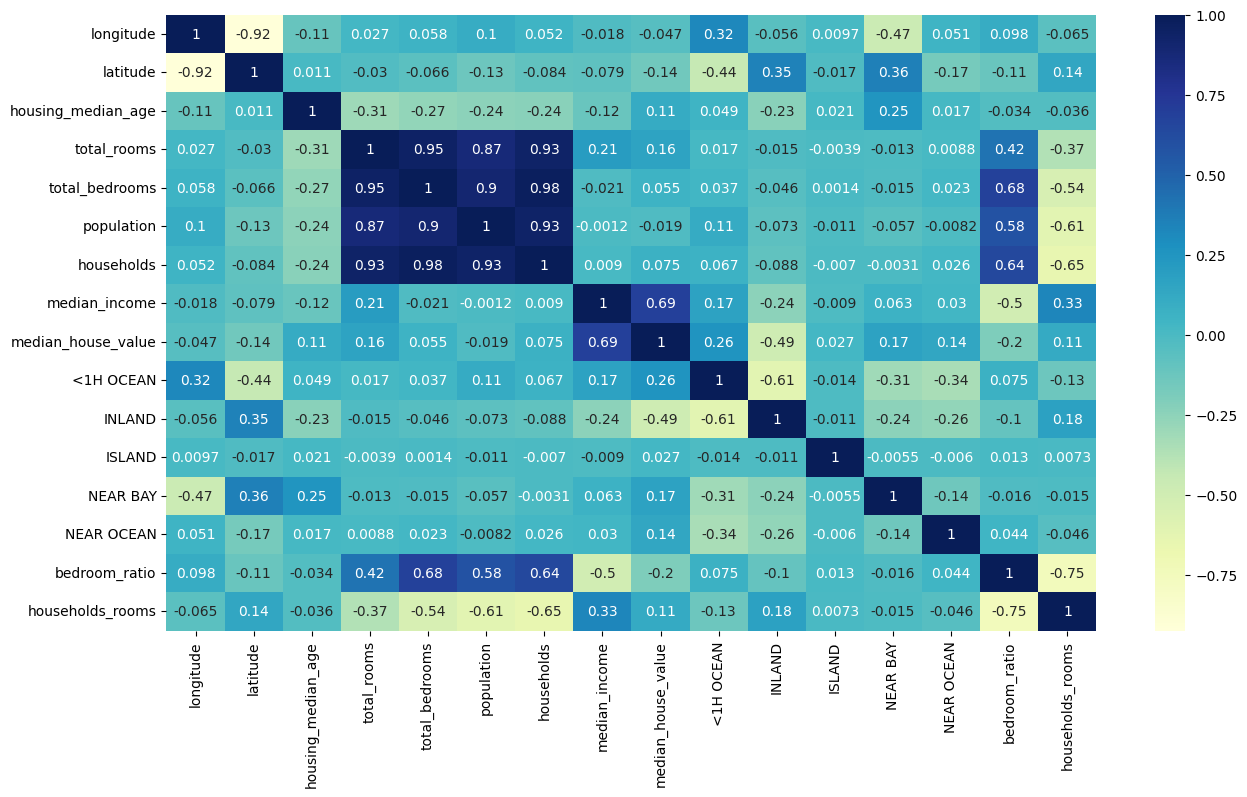

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

#Linear Regression Model


most simple model we can train

In [ ]:
from sklearn.linear_model import LinearRegression

x_train, y_train = train_data.drop(['median_house_value'], axis=1 ), train_data['median_house_value']

reg = LinearRegression()

reg.fit(x_train, y_train)

LinearRegression()

now all we did for the train data, we will do for **test data**

In [ ]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1 )

test_data = test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['households_rooms'] = test_data['total_rooms'] / test_data['households']

In [ ]:
x_test, y_test = test_data.drop(['median_house_value'], axis=1 ), test_data['median_house_value']

In [ ]:
reg.score(x_test, y_test)

0.6764285150240512

#Scaling

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(x_train)
x_test_s = scaler.transform(x_test)

x_train_s = scaler.fit_transform(x_train)

note about :

```
scaler.fit(x_train)
```

When you're preprocessing data, especially for tasks like scaling, you should always fit your scaler (or any other preprocessing transformer) on your training data and then use the same scaler to transform both your training and test data.


NOTE that you ***can not*** instead of last code, use this:

```
❌scaler.fit(x_test)❌
```
If you fit the scaler on the test data separately, you would introduce information from the test set into the training process, which could lead to data leakage and unrealistic evaluation of your model's performance.


# Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor() #the estimator

rf_reg.fit(x_train, y_train)
# or you could've do this instead of last two lines ==> RandomForestRegressor.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
rf_reg.score(x_test, y_test)

0.8216689886463009

In [ ]:
#Scaling_result
rf_reg.fit(x_train_s, y_train)


RandomForestRegressor()

In [ ]:
rf_reg.score(x_test_s, y_test)

0.8201701281195052

# ***Tuning***

# greed search with cross validation (greedsearchcv)



***cross*** ***validation***: take the data -- split it inro K (a number) folds -- use (K-1) fold to train the data and one fold for the testing

ex: If you have 10 folds, you use 9 for training and one for testing

 you do that for all possible combinations and then you evaluate the
31:39
parameters that you used for this one run for this one iteration

توضیح ***گرید سرچ***: ما یه الگوریتم ماشین لرنینگ مدل مون رو ترین کردیم مثل اینجا رندوم فورست
هر الگوریتم ماشین لرنینگ یه سری هایپر پارامتر داره و این رندوم فورست هم یه سری هاپیرپارامتر ها داره//
حالا ما الان با الگوریتم خودممو مدلمون رو ترین کردیم اما نتیجه بهتری میخوایم پس اینجا میایم تونینگ انجام میدیم//
  حالا ما میخوام تونینگ انجام بدیم تا بتونیم نتیجه بهتری بگیریم، یکی از تکنیک های تونینگ میشه به گرید سرچ اشاره کرد (تکنیک های دیگه ای هم داره مثل رندوم سرچ و غیره) //
حالا این گرید سرچ چطور کار میکنه؟//
میاد تماام حالت های ممکنی که هایپر پاارامترهایی که میتونن باهم بگیرن رو در نظر میگیره در فضای حالت و تموم فضای حالت رو سرچ میکنه طبعا برای فضای حالت کوچیک کارا ست اما برای فضای حالت های بزرگتر اصلا مناسب نیست و زندگی سخت میشه

For each combination of hyperparameters in the grid, the model is trained and evaluated using ***cross-validation***.
The performance of the model is averaged across all cross-validation folds.
The combination of hyperparameters that yields the best average performance is selected as the optimal set of hyperparameters.
In summary, grid search uses cross-validation to evaluate the performance of different hyperparameter combinations, helping to ensure that the chosen hyperparameters generalize well to unseen data.

 ***Gridsearchcv***

Here's how the process typically works:



*   For each combination of hyperparameters in the grid, the model is trained and evaluated using cross-validation.
*   The performance of the model is averaged across all cross-validation folds.
*   The combination of hyperparameters that yields the best average performance is selected as the optimal set of hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_reg = RandomForestRegressor()

param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [2, 4],
    "max_depth": [None, 4, 8]
    # we need to change the valid value or the hyperparametr itself to get better result
    #HINT: would be better to set a defult as the first valid value and then increase  it
}



In [ ]:
grid_search = GridSearchCV(rf_reg,param_grid, cv=5,scoring="neg_mean_squared_error", return_train_score=True  )


In [ ]:
grid_search.fit(x_train_s, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'min_samples_split': [2, 4],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
best_estimator = grid_search.best_estimator_

In [ ]:
best_estimator.score(x_test_s, y_test)

0.8218870525804898